In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
from sklearn.base import clone

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("\nClass distribution:")
print(pd.Series(data.target_names[y]).value_counts())

Samples: 569
Features: 30

Class distribution:
benign       357
malignant    212
Name: count, dtype: int64


Missing values: 0
Duplicate rows: 0


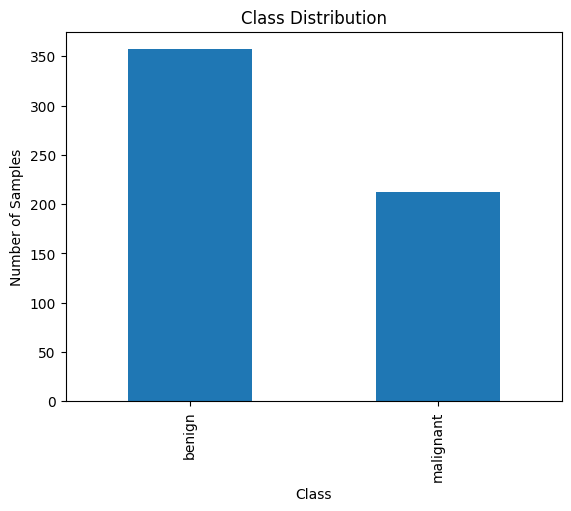

In [ ]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

class_distribution = pd.Series(data.target_names[y]).value_counts()

class_distribution.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


PCA Design Choice

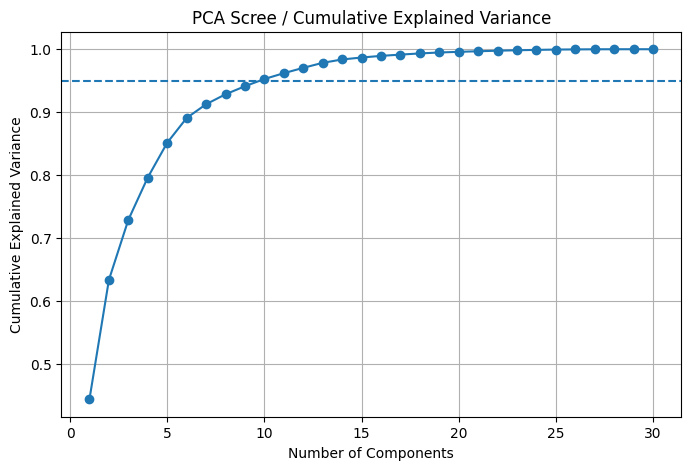

Components selected: 10
Explained variance: 95.27 %


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree / Cumulative Explained Variance")
plt.grid()
plt.show()

n_components = np.argmax(cumulative >= 0.95) + 1
variance_target = cumulative[n_components - 1] * 100

print("Components selected:", n_components)
print("Explained variance:", round(variance_target, 2), "%")

In [ ]:
pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": [
        f"{n_components} components / 95%"
    ],
    "Explained Variance (%)": [round(variance_target, 2)],
    "Justification": [
        "95% variance was retained while reducing the number of features."
    ]
})

pca_summary

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components / 95%,95.27,95% variance was retained while reducing the n...


Hyperparameter grids

In [ ]:
models = {
    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "model__kernel": ["linear", "rbf"],
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"]
        }
    ),
    "Naive Bayes": (
        GaussianNB(),
        {
            "model__var_smoothing": [1e-09, 1e-08, 1e-07]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=5000, random_state=42),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "model__max_depth": [3, 5, 7, None],
            "model__min_samples_split": [2, 5, 10],
            "model__criterion": ["gini", "entropy"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__max_features": ["sqrt", "log2"]
        }
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 1]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    ),
    "XGBoost": (
        XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    )
}

Model tuning without PCA

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

no_pca_best = {}
no_pca_tuning = []

for name, (estimator, grid) in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

    search = GridSearchCV(
        pipe,
        grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    no_pca_best[name] = search.best_estimator_

    no_pca_tuning.append({
        "Model": name,
        "Best Parameters": search.best_params_,
        "Best CV Accuracy (%)": round(search.best_score_ * 100, 2)
    })

no_pca_tuning_df = pd.DataFrame(no_pca_tuning)
no_pca_tuning_df

,Model,Best Parameters,Best CV Accuracy (%)
0,SVM,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",97.58
1,Naive Bayes,{'model__var_smoothing': 1e-09},93.41
2,KNN,"{'model__metric': 'manhattan', 'model__n_neigh...",97.14
3,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'liblinear'}",98.24
4,Decision Tree,"{'model__criterion': 'entropy', 'model__max_de...",93.19
5,Random Forest,"{'model__max_depth': None, 'model__max_feature...",96.48
6,AdaBoost,"{'model__learning_rate': 1, 'model__n_estimato...",98.02
7,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",96.26
8,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",97.14


Model tuning with PCA

In [ ]:
pca_best = {}
pca_tuning = {}

for name, (estimator, grid) in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", estimator)
    ])

    search = GridSearchCV(
        pipe,
        grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    pca_best[name] = search.best_estimator_

    pca_tuning[name] = {
        "Model": name,
        "Best Parameters": search.best_params_,
        "Best CV Accuracy (%)": round(search.best_score_ * 100, 2)
    }

pca_tuning_df = pd.DataFrame(pca_tuning.values())
pca_tuning_df

,Model,Best Parameters,Best CV Accuracy (%)
0,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",98.02
1,Naive Bayes,{'model__var_smoothing': 1e-09},92.75
2,KNN,"{'model__metric': 'euclidean', 'model__n_neigh...",96.70
3,Logistic Regression,"{'model__C': 1, 'model__solver': 'lbfgs'}",98.24
4,Decision Tree,"{'model__criterion': 'entropy', 'model__max_de...",93.63
5,Random Forest,"{'model__max_depth': None, 'model__max_feature...",95.82
6,AdaBoost,"{'model__learning_rate': 1, 'model__n_estimato...",97.58
7,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",95.82
8,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",96.48


Stacking

In [ ]:
stack_estimators = [
    ("svm", Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(C=1, kernel="rbf", probability=True, random_state=42))
    ])),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(max_depth=5, random_state=42))
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5
)

stack_grid = {
    "final_estimator__C": [0.1, 1, 10]
}

stack_no_pca = GridSearchCV(
    stack_model,
    stack_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

stack_no_pca.fit(X_train, y_train)

no_pca_best["Stacking"] = stack_no_pca.best_estimator_

stack_pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=5000, random_state=42),
        cv=5
    ))
])

stack_pca_grid = {
    "model__final_estimator__C": [0.1, 1, 10]
}

stack_pca = GridSearchCV(
    stack_pca_model,
    stack_pca_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

stack_pca.fit(X_train, y_train)

pca_best["Stacking"] = stack_pca.best_estimator_

stack_tuning_df = pd.DataFrame([
    {
        "Setting": "No-PCA",
        "Base Learners": "SVM + Naive Bayes + Decision Tree",
        "Meta Learner": "Logistic Regression",
        "Best Parameters": stack_no_pca.best_params_,
        "Best CV Accuracy (%)": round(stack_no_pca.best_score_ * 100, 2)
    },
    {
        "Setting": "With-PCA",
        "Base Learners": "SVM + Naive Bayes + Decision Tree",
        "Meta Learner": "Logistic Regression",
        "Best Parameters": stack_pca.best_params_,
        "Best CV Accuracy (%)": round(stack_pca.best_score_ * 100, 2)
    }
])

stack_tuning_df

,Setting,Base Learners,Meta Learner,Best Parameters,Best CV Accuracy (%)
0,No-PCA,SVM + Naive Bayes + Decision Tree,Logistic Regression,{'final_estimator__C': 10},97.14
1,With-PCA,SVM + Naive Bayes + Decision Tree,Logistic Regression,{'model__final_estimator__C': 10},97.58


In [ ]:
all_best = list(models.keys()) + ["Stacking"]

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred) * 100, 2),
        "ROC-AUC (%)": round(roc_auc_score(y_test, y_prob) * 100, 2)
    }

performance_rows = []

for name in all_best:
    performance_rows.append({
        "Model": name,
        "Setting": "No-PCA",
        **evaluate_model(no_pca_best[name], X_test, y_test)
    })

    performance_rows.append({
        "Model": name,
        "Setting": "With-PCA",
        **evaluate_model(pca_best[name], X_test, y_test)
    })

performance_df = pd.DataFrame(performance_rows)
performance_df

,Model,Setting,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
0,SVM,No-PCA,98.25,98.61,98.61,98.61,99.37
1,SVM,With-PCA,96.49,98.57,95.83,97.18,99.47
2,Naive Bayes,No-PCA,92.98,94.44,94.44,94.44,98.68
3,Naive Bayes,With-PCA,92.11,93.15,94.44,93.79,97.09
4,KNN,No-PCA,96.49,95.95,98.61,97.26,97.14
5,KNN,With-PCA,95.61,95.89,97.22,96.55,98.16
6,Logistic Regression,No-PCA,98.25,98.61,98.61,98.61,99.60
7,Logistic Regression,With-PCA,97.37,98.59,97.22,97.90,99.54
8,Decision Tree,No-PCA,94.74,94.59,97.22,95.89,94.48
9,Decision Tree,With-PCA,92.98,94.44,94.44,94.44,94.26


5-Fold Cross-Validation Results

In [ ]:
cv_rows = []

for name in all_best:
    for setting, model in [("No-PCA", no_pca_best[name]), ("With-PCA", pca_best[name])]:
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=["accuracy", "f1"],
            n_jobs=-1
        )

        cv_rows.append({
            "Model": name,
            "Setting": setting,
            "Fold 1 Accuracy (%)": round(scores["test_accuracy"][0] * 100, 2),
            "Fold 2 Accuracy (%)": round(scores["test_accuracy"][1] * 100, 2),
            "Fold 3 Accuracy (%)": round(scores["test_accuracy"][2] * 100, 2),
            "Fold 4 Accuracy (%)": round(scores["test_accuracy"][3] * 100, 2),
            "Fold 5 Accuracy (%)": round(scores["test_accuracy"][4] * 100, 2),
            "Average Accuracy (%)": round(scores["test_accuracy"].mean() * 100, 2),
            "Average F1 (%)": round(scores["test_f1"].mean() * 100, 2)
        })

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df

,Model,Setting,Fold 1 Accuracy (%),Fold 2 Accuracy (%),Fold 3 Accuracy (%),Fold 4 Accuracy (%),Fold 5 Accuracy (%),Average Accuracy (%),Average F1 (%)
0,SVM,No-PCA,95.60,97.80,97.80,97.80,98.90,97.58,98.10
1,SVM,With-PCA,96.70,98.90,98.90,97.80,97.80,98.02,98.43
2,Naive Bayes,No-PCA,91.21,96.70,89.01,95.60,94.51,93.41,94.78
3,Naive Bayes,With-PCA,90.11,94.51,91.21,94.51,93.41,92.75,94.33
4,KNN,No-PCA,97.80,98.90,95.60,95.60,97.80,97.14,97.74
5,KNN,With-PCA,95.60,98.90,94.51,96.70,97.80,96.70,97.41
6,Logistic Regression,No-PCA,97.80,97.80,98.90,98.90,97.80,98.24,98.61
7,Logistic Regression,With-PCA,97.80,98.90,98.90,97.80,97.80,98.24,98.61
8,Decision Tree,No-PCA,90.11,94.51,91.21,93.41,96.70,93.19,94.64
9,Decision Tree,With-PCA,90.11,93.41,93.41,96.70,94.51,93.63,94.87


In [ ]:
cv_accuracy_table = cv_results_df.pivot(
    index="Model",
    columns="Setting",
    values="Average Accuracy (%)"
).reset_index()

cv_accuracy_table

Setting,Model,No-PCA,With-PCA
0,AdaBoost,98.02,97.58
1,Decision Tree,93.19,93.63
2,Gradient Boosting,96.26,95.82
3,KNN,97.14,96.70
4,Logistic Regression,98.24,98.24
5,Naive Bayes,93.41,92.75
6,Random Forest,96.48,95.82
7,SVM,97.58,98.02
8,Stacking,97.14,97.58
9,XGBoost,97.14,96.48


Hyperparameter tuning tables

In [ ]:
svm_table = no_pca_tuning_df[no_pca_tuning_df["Model"] == "SVM"].copy()
svm_pca_table = pca_tuning_df[pca_tuning_df["Model"] == "SVM"].copy()

nb_table = no_pca_tuning_df[no_pca_tuning_df["Model"] == "Naive Bayes"].copy()
nb_pca_table = pca_tuning_df[pca_tuning_df["Model"] == "Naive Bayes"].copy()

knn_table = no_pca_tuning_df[no_pca_tuning_df["Model"] == "KNN"].copy()
knn_pca_table = pca_tuning_df[pca_tuning_df["Model"] == "KNN"].copy()

pd.concat([
    no_pca_tuning_df,
    pca_tuning_df
], ignore_index=True)

,Model,Best Parameters,Best CV Accuracy (%)
0,SVM,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",97.58
1,Naive Bayes,{'model__var_smoothing': 1e-09},93.41
2,KNN,"{'model__metric': 'manhattan', 'model__n_neigh...",97.14
3,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'liblinear'}",98.24
4,Decision Tree,"{'model__criterion': 'entropy', 'model__max_de...",93.19
5,Random Forest,"{'model__max_depth': None, 'model__max_feature...",96.48
6,AdaBoost,"{'model__learning_rate': 1, 'model__n_estimato...",98.02
7,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",96.26
8,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",97.14
9,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",98.02


Confusion matrices

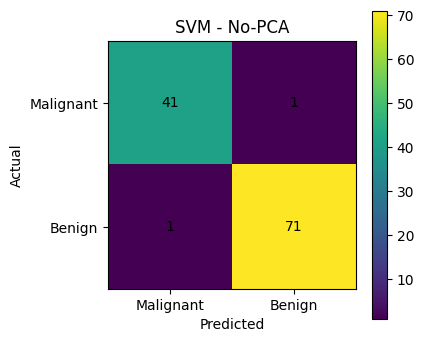

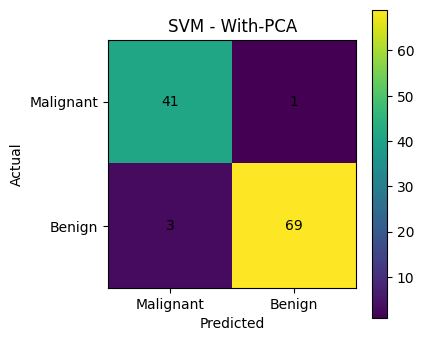

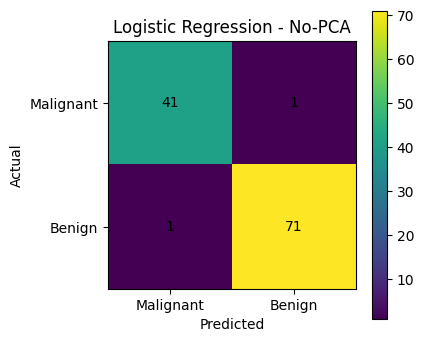

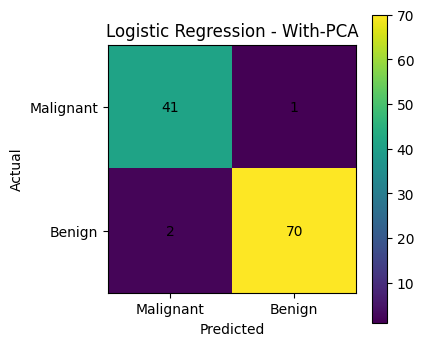

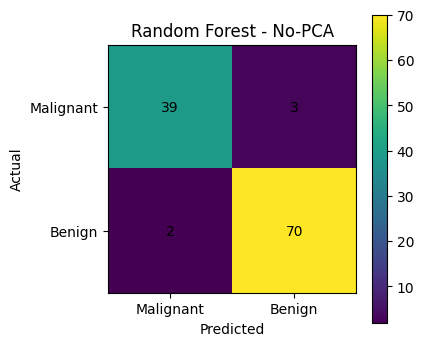

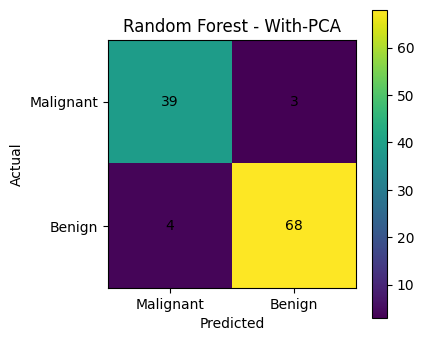

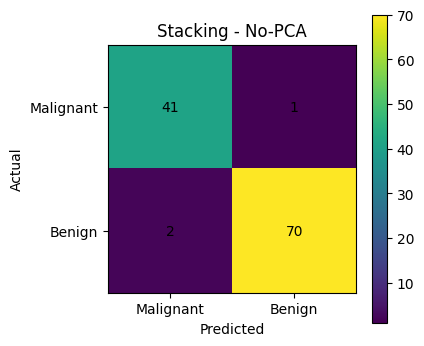

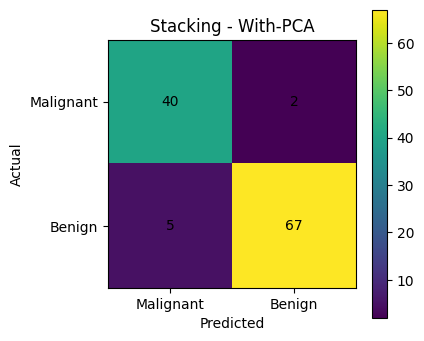

In [ ]:
selected_models = ["SVM", "Logistic Regression", "Random Forest", "Stacking"]

for name in selected_models:
    for setting, model in [("No-PCA", no_pca_best[name]), ("With-PCA", pca_best[name])]:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(4, 4))
        plt.imshow(cm)
        plt.title(f"{name} - {setting}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.xticks([0, 1], ["Malignant", "Benign"])
        plt.yticks([0, 1], ["Malignant", "Benign"])

        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i, j], ha="center", va="center")

        plt.colorbar()
        plt.show()

ROC curves

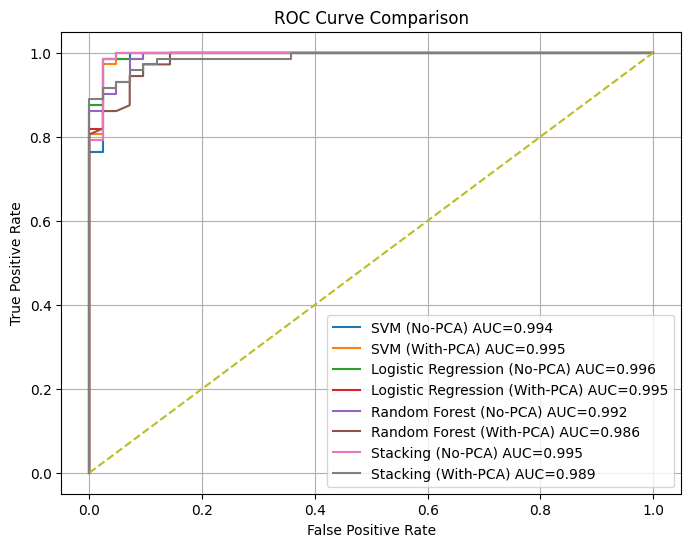

In [ ]:
plt.figure(figsize=(8, 6))

for name in selected_models:
    for setting, model in [("No-PCA", no_pca_best[name]), ("With-PCA", pca_best[name])]:
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_value = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} ({setting}) AUC={auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

Precision-Recall curves

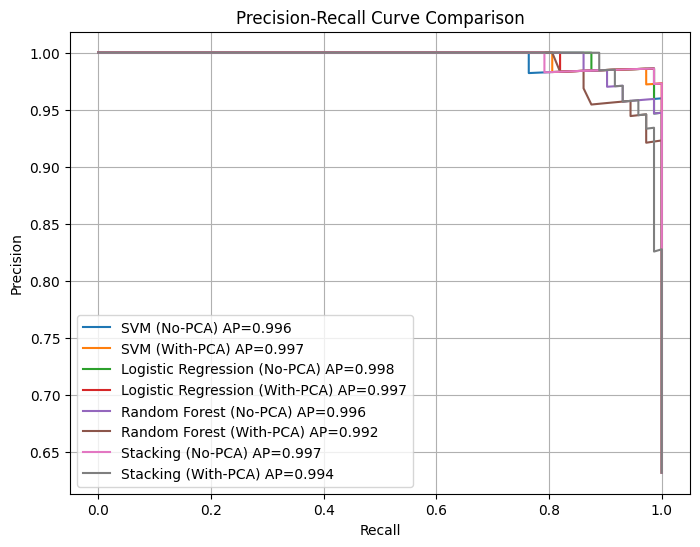

In [ ]:
plt.figure(figsize=(8, 6))

for name in selected_models:
    for setting, model in [("No-PCA", no_pca_best[name]), ("With-PCA", pca_best[name])]:
        y_prob = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        plt.plot(recall, precision, label=f"{name} ({setting}) AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.show()

PCA comparison

In [ ]:
comparison = performance_df.pivot(
    index="Model",
    columns="Setting",
    values=["Accuracy (%)", "F1 Score (%)", "ROC-AUC (%)"]
)

comparison

Accuracy (%)          F1 Score (%)          ROC-AUC (%)  \
Setting                   No-PCA With-PCA       No-PCA With-PCA      No-PCA   
Model                                                                         
AdaBoost                   95.61    94.74        96.60    95.83       98.18   
Decision Tree              94.74    92.98        95.89    94.44       94.48   
Gradient Boosting          94.74    93.86        95.89    95.17       99.07   
KNN                        96.49    95.61        97.26    96.55       97.14   
Logistic Regression        98.25    97.37        98.61    97.90       99.60   
Naive Bayes                92.98    92.11        94.44    93.79       98.68   
Random Forest              95.61    93.86        96.55    95.10       99.24   
SVM                        98.25    96.49        98.61    97.18       99.37   
Stacking                   97.37    93.86        97.90    95.04       99.47   
XGBoost                    94.74    94.74        95.89    95.83       99.34   

                              
Setting             With-PCA  
Model                         
AdaBoost               98.38  
Decision Tree          94.26  
Gradient Boosting      98.58  
KNN                    98.16  
Logistic Regression    99.54  
Naive Bayes            97.09  
Random Forest          98.64  
SVM                    99.47  
Stacking               98.88  
XGBoost                99.27

In [ ]:
comparison_change = pd.DataFrame({
    "Accuracy Change (%)": [
        performance_df[
            (performance_df["Model"] == name) &
            (performance_df["Setting"] == "With-PCA")
        ]["Accuracy (%)"].iloc[0]
        -
        performance_df[
            (performance_df["Model"] == name) &
            (performance_df["Setting"] == "No-PCA")
        ]["Accuracy (%)"].iloc[0]
        for name in all_best
    ],
    "F1 Change (%)": [
        performance_df[
            (performance_df["Model"] == name) &
            (performance_df["Setting"] == "With-PCA")
        ]["F1 Score (%)"].iloc[0]
        -
        performance_df[
            (performance_df["Model"] == name) &
            (performance_df["Setting"] == "No-PCA")
        ]["F1 Score (%)"].iloc[0]
        for name in all_best
    ]
}, index=all_best)

comparison_change

,Accuracy Change (%),F1 Change (%)
SVM,-1.76,-1.43
Naive Bayes,-0.87,-0.65
KNN,-0.88,-0.71
Logistic Regression,-0.88,-0.71
Decision Tree,-1.76,-1.45
Random Forest,-1.75,-1.45
AdaBoost,-0.87,-0.77
Gradient Boosting,-0.88,-0.72
XGBoost,0.00,-0.06
Stacking,-3.51,-2.86


Final results

In [ ]:
best_result = performance_df.loc[
    performance_df["Accuracy (%)"].idxmax()
]

print("Best model:", best_result["Model"])
print("Setting:", best_result["Setting"])
print("Accuracy:", best_result["Accuracy (%)"])
print("F1 Score:", best_result["F1 Score (%)"])
print("ROC-AUC:", best_result["ROC-AUC (%)"])

Best model: SVM
Setting: No-PCA
Accuracy: 98.25
F1 Score: 98.61
ROC-AUC: 99.37


In [ ]:
print("No-PCA vs With-PCA Cross-Validation Results")
display(cv_results_df)

print("\nTest Set Performance")
display(performance_df)

print("\nPCA Summary")
display(pca_summary)

No-PCA vs With-PCA Cross-Validation Results


,Model,Setting,Fold 1 Accuracy (%),Fold 2 Accuracy (%),Fold 3 Accuracy (%),Fold 4 Accuracy (%),Fold 5 Accuracy (%),Average Accuracy (%),Average F1 (%)
0,SVM,No-PCA,95.60,97.80,97.80,97.80,98.90,97.58,98.10
1,SVM,With-PCA,96.70,98.90,98.90,97.80,97.80,98.02,98.43
2,Naive Bayes,No-PCA,91.21,96.70,89.01,95.60,94.51,93.41,94.78
3,Naive Bayes,With-PCA,90.11,94.51,91.21,94.51,93.41,92.75,94.33
4,KNN,No-PCA,97.80,98.90,95.60,95.60,97.80,97.14,97.74
5,KNN,With-PCA,95.60,98.90,94.51,96.70,97.80,96.70,97.41
6,Logistic Regression,No-PCA,97.80,97.80,98.90,98.90,97.80,98.24,98.61
7,Logistic Regression,With-PCA,97.80,98.90,98.90,97.80,97.80,98.24,98.61
8,Decision Tree,No-PCA,90.11,94.51,91.21,93.41,96.70,93.19,94.64
9,Decision Tree,With-PCA,90.11,93.41,93.41,96.70,94.51,93.63,94.87



Test Set Performance


,Model,Setting,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
0,SVM,No-PCA,98.25,98.61,98.61,98.61,99.37
1,SVM,With-PCA,96.49,98.57,95.83,97.18,99.47
2,Naive Bayes,No-PCA,92.98,94.44,94.44,94.44,98.68
3,Naive Bayes,With-PCA,92.11,93.15,94.44,93.79,97.09
4,KNN,No-PCA,96.49,95.95,98.61,97.26,97.14
5,KNN,With-PCA,95.61,95.89,97.22,96.55,98.16
6,Logistic Regression,No-PCA,98.25,98.61,98.61,98.61,99.60
7,Logistic Regression,With-PCA,97.37,98.59,97.22,97.90,99.54
8,Decision Tree,No-PCA,94.74,94.59,97.22,95.89,94.48
9,Decision Tree,With-PCA,92.98,94.44,94.44,94.44,94.26



PCA Summary


,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components / 95%,95.27,95% variance was retained while reducing the n...
